In [1]:
import pandas as pd

PHASE 1 – BUSINESS UNDERSTANDING & PROBLEM FRAMING

Project Title:
Electricity Consumption & Demand Forecasting:
EDA, Visualization and Executive Story

Domain:
Energy

Primary Objective:
To analyse electricity consumption and demand data,
identify meaningful patterns and performance drivers,
and develop a reliable forecasting approach when
supported by the dataset.

Business Challenge:
To transform energy-related data into reliable evidence
for understanding patterns, distributions and performance
drivers and support better decision-making.

Key Stakeholders:
- Energy Management Team
- Operations Team
- Management / Executives
- Planning Team
- Data Analysts

Main Business Focus:
Electricity consumption / demand analysis and forecasting.

Scope:
- Generation
- Consumption
- Prices (if available)
- Sectors (if available)
- Time
- Geography

Success Criteria:
- Clean and validated data
- Meaningful KPIs
- EDA
- 6+ visualisations
- Statistical test
- Predictive model (if valid target exists)
- Time-series forecasting (if timestamps support it)
- Business recommendations
- Reproducible analysis

Load Dataset

In [2]:
df = pd.read_excel(
    "../Data_understanding/Project_106_Unclean_Energy_Dataset_5000.xlsx",
    sheet_name="Unclean_Data"
)

df.head()

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
0,103461,2024-05-24 04:00:00,California,INDUSTRIAL,981.86,1139.91,1128.04,51.60,23.41,40.42,No
1,103959,2024-06-13 22:00:00,Texas,Industrial,1040.52,972.13,1047.89,52.96,27.82,67.81,No
2,100066,2024-01-03 17:00:00,Florida,Residential,920.08,895.03,969.66,58.09,35.91,45.49,No
3,102520,2024-04-14 23:00:00,Texas,Residential,686.13,758.59,699.00,50.12,37.10,33.45,No
4,100394,2024-01-17 09:00:00,california,NaN,1507.38,1745.83,1596.02,65.08,19.39,59.06,Yes


Dataset Shape

In [3]:
df.shape

(5045, 11)

Columns

DataType

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5045 entries, 0 to 5044
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Record_ID                      5045 non-null   int64  
 1   Date_Time                      5045 non-null   object 
 2   State                          4919 non-null   str    
 3   Sector                         4943 non-null   str    
 4   Consumption_MWh                4955 non-null   float64
 5   Peak_Demand_MW                 4970 non-null   float64
 6   Generation_MWh                 4943 non-null   float64
 7   Electricity_Price_USD_per_MWh  4935 non-null   float64
 8   Renewable_Share_Pct            4954 non-null   float64
 9   Weather_Index                  4919 non-null   float64
 10  Peak_Flag                      5045 non-null   str    
dtypes: float64(6), int64(1), object(1), str(3)
memory usage: 433.7+ KB


Row Grain


In [5]:
df.head()

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
0,103461,2024-05-24 04:00:00,California,INDUSTRIAL,981.86,1139.91,1128.04,51.60,23.41,40.42,No
1,103959,2024-06-13 22:00:00,Texas,Industrial,1040.52,972.13,1047.89,52.96,27.82,67.81,No
2,100066,2024-01-03 17:00:00,Florida,Residential,920.08,895.03,969.66,58.09,35.91,45.49,No
3,102520,2024-04-14 23:00:00,Texas,Residential,686.13,758.59,699.00,50.12,37.10,33.45,No
4,100394,2024-01-17 09:00:00,california,NaN,1507.38,1745.83,1596.02,65.08,19.39,59.06,Yes


In [6]:
df.nunique()

Record_ID                        5020
Date_Time                        4996
State                              11
Sector                             14
Consumption_MWh                  4817
Peak_Demand_MW                   4803
Generation_MWh                   4778
Electricity_Price_USD_per_MWh    2532
Renewable_Share_Pct              2859
Weather_Index                    3262
Peak_Flag                           2
dtype: int64

## Data Dictionary

| Column | Meaning | Data Type | Variable Role |
|---|---|---|---|
| Record_ID | Unique record identifier | Integer | Identifier |
| Date_Time | Date and time of observation | Datetime | Time variable |
| State | Geographic state | Categorical | Feature |
| Sector | Energy consumption sector | Categorical | Feature |
| Consumption_MWh | Electricity consumption in MWh | Numeric | Target/Measure |
| Peak_Demand_MW | Peak electricity demand in MW | Numeric | Target/Measure |
| Generation_MWh | Electricity generation in MWh | Numeric | Feature/Measure |
| Electricity_Price_USD_per_MWh | Electricity price per MWh | Numeric | Feature/Measure |
| Renewable_Share_Pct | Renewable energy share (%) | Numeric | Feature |
| Weather_Index | Weather-related index | Numeric | Feature |
| Peak_Flag | Indicates whether demand is high | Categorical | Target |

## Row Grain

One row represents one electricity observation
for a specific date/time, state and sector.

Dataset summary check


In [7]:
df.describe(include="all")

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
count,5.045000e+03,5045,4919,4943,4955.000000,4970.000000,4943.000000,4935.000000,4954.000000,4919.000000,5045
unique,NaN,4996,11,14,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,2024-03-10 13:00:00,Texas,Residential,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,2,905,1193,NaN,NaN,NaN,NaN,NaN,NaN,4291
mean,1.060687e+05,NaN,NaN,NaN,977.305026,1021.572631,1050.402880,55.156916,31.017164,49.588632,NaN
std,5.660107e+04,NaN,NaN,NaN,335.554981,344.853975,359.340047,13.051276,11.393050,15.260701,NaN
min,1.000010e+05,NaN,NaN,NaN,-1330.550000,317.010000,-1695.030000,-63.160000,-12.000000,-16.980000,NaN
25%,1.012580e+05,NaN,NaN,NaN,775.385000,800.512500,831.150000,49.455000,23.310000,39.095000,NaN
50%,1.025060e+05,NaN,NaN,NaN,955.400000,990.230000,1024.210000,55.090000,31.025000,49.550000,NaN
75%,1.037620e+05,NaN,NaN,NaN,1158.335000,1206.600000,1248.435000,60.575000,38.617500,59.995000,NaN


Unique values check


In [8]:
df.nunique()

Record_ID                        5020
Date_Time                        4996
State                              11
Sector                             14
Consumption_MWh                  4817
Peak_Demand_MW                   4803
Generation_MWh                   4778
Electricity_Price_USD_per_MWh    2532
Renewable_Share_Pct              2859
Weather_Index                    3262
Peak_Flag                           2
dtype: int64

Categorical values inspect

In [9]:
print(df["State"].unique())
print(df["Sector"].unique())
print(df["Peak_Flag"].unique())

<StringArray>
['California',      'Texas',    'Florida',     'Texas ', 'california',
   'NEW YORK',   'New York',          nan, 'CALIFORNIA',    'FLORIDA',
      'TEXAS',     'TEXAS ']
Length: 12, dtype: str
<StringArray>
[   'INDUSTRIAL',    'Industrial',   'Residential',             nan,
   'residential',    'Commercial',   'Commercial ', ' Residential ',
    'industrial',  ' Industrial ',  ' Commercial ',    'COMMERCIAL',
  ' INDUSTRIAL ',   'RESIDENTIAL', ' residential ']
Length: 15, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


Data Audit & Cleaning.

Missing Values Audit


In [10]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing

,Missing_Count,Missing_Percentage
Record_ID,0,0.00
Date_Time,0,0.00
State,126,2.50
Sector,102,2.02
Consumption_MWh,90,1.78
Peak_Demand_MW,75,1.49
Generation_MWh,102,2.02
Electricity_Price_USD_per_MWh,110,2.18
Renewable_Share_Pct,91,1.80
Weather_Index,126,2.50


Duplicate Audit

In [11]:
df.duplicated().sum()

np.int64(25)

In [12]:
df[df.duplicated()]

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
2026,104110,2024-06-20 05:00:00,Florida,residential,596.71,638.34,673.64,54.53,52.74,51.93,No
2040,101965,2024-03-22 20:00:00,Florida,Commercial,1057.51,1059.49,1174.90,59.64,24.50,27.73,No
2351,100638,2024-01-27 13:00:00,California,Commercial,1080.55,1234.43,1157.38,31.64,25.60,42.60,No
2374,103078,2024-05-08 05:00:00,Texas,Industrial,1027.77,1048.95,1151.63,62.70,37.58,65.20,No
2473,102179,2024-03-31 18:00:00,Texas,Residential,1068.33,1100.11,1160.21,53.82,39.71,41.12,No
2511,102046,2024-03-26 05:00:00,Texas,Commercial,745.16,875.92,847.02,67.49,42.99,47.97,No
2615,104770,2024-07-17 17:00:00,California,Residential,892.05,956.52,972.29,58.19,45.70,54.08,No
2793,102933,2024-05-02 04:00:00,Texas,Industrial,1029.53,1146.36,1179.74,65.87,19.93,65.35,No
2822,100218,2024-01-10 01:00:00,Texas,residential,801.03,911.28,803.14,53.95,17.99,63.74,No
2917,101353,2024-02-26 08:00:00,New York,Residential,845.72,974.36,920.27,58.56,38.20,75.37,No


In [13]:
(df.duplicated().sum() / len(df) * 100).round(2)

np.float64(0.5)

Business-key duplicates
Date_Time + State + Sector

In [14]:
df.duplicated(
    subset=["Date_Time", "State", "Sector"]
).sum()

np.int64(45)

In [15]:
df.duplicated().sum()

np.int64(25)

Data Type Audit

In [16]:
df.dtypes

Record_ID                          int64
Date_Time                         object
State                                str
Sector                               str
Consumption_MWh                  float64
Peak_Demand_MW                   float64
Generation_MWh                   float64
Electricity_Price_USD_per_MWh    float64
Renewable_Share_Pct              float64
Weather_Index                    float64
Peak_Flag                            str
dtype: object

Date-Time Validation

In [17]:
df["Date_Time"].head(10)

0    2024-05-24 04:00:00
1    2024-06-13 22:00:00
2    2024-01-03 17:00:00
3    2024-04-14 23:00:00
4    2024-01-17 09:00:00
5    2024-01-08 11:00:00
6    2024-04-21 22:00:00
7    2024-03-10 13:00:00
8    2024-01-14 21:00:00
9    2024-02-20 09:00:00
Name: Date_Time, dtype: object

In [18]:
pd.to_datetime(df["Date_Time"], errors="coerce")

0      2024-05-24 04:00:00
1      2024-06-13 22:00:00
2      2024-01-03 17:00:00
3      2024-04-14 23:00:00
4      2024-01-17 09:00:00
               ...        
5040   2024-07-03 10:00:00
5041   2024-01-20 10:00:00
5042   2024-05-08 20:00:00
5043   2024-06-06 04:00:00
5044   2024-02-05 20:00:00
Name: Date_Time, Length: 5045, dtype: datetime64[us]

Invalid dates count

In [19]:
pd.to_datetime(df["Date_Time"], errors="coerce").isna().sum()


np.int64(8)

In [20]:
invalid_dates = df[pd.to_datetime(df["Date_Time"], errors="coerce").isna()]

invalid_dates[["Record_ID", "Date_Time"]]

,Record_ID,Date_Time
297,103228,2024/00/15 08:00
685,101130,unknown
690,103162,99/99/2024 20:00
1649,103095,31/11/2024 09:00
1790,102648,2024-13-05 12:00
3309,100090,2024-02-30 10:00
3606,104100,2024-04-31 15:00
4510,101959,not_available


Invalid dates count verify

In [21]:
len(invalid_dates)

8

In [22]:
invalid_dates = df[pd.to_datetime(df["Date_Time"], errors="coerce").isna()]

invalid_dates[["Record_ID", "Date_Time"]]

,Record_ID,Date_Time
297,103228,2024/00/15 08:00
685,101130,unknown
690,103162,99/99/2024 20:00
1649,103095,31/11/2024 09:00
1790,102648,2024-13-05 12:00
3309,100090,2024-02-30 10:00
3606,104100,2024-04-31 15:00
4510,101959,not_available


Date-Time Conversion

In [23]:
df_clean = df.copy()

In [24]:
df_clean["Date_Time"] = pd.to_datetime(
    df_clean["Date_Time"],
    errors="coerce"
)

In [25]:
df_clean["Date_Time"].isna().sum()

np.int64(8)

Remove Invalid Date Rows

In [26]:
df_clean = df_clean.dropna(subset=["Date_Time"]).copy()

In [27]:
df_clean.shape

(5037, 11)

Categorical Data Audit

In [28]:
df_clean["State"].value_counts()

State
Texas         903
California    821
Florida       747
New York      709
Texas         596
california    590
NEW YORK      531
TEXAS           6
CALIFORNIA      4
FLORIDA         3
TEXAS           2
Name: count, dtype: int64

In [29]:
df_clean["Sector"].value_counts()

Sector
Residential      1189
Commercial       1129
Industrial        897
residential       655
Commercial        559
INDUSTRIAL        473
 Residential        8
COMMERCIAL          6
 Industrial         4
 Commercial         4
RESIDENTIAL         4
industrial          3
 residential        3
 INDUSTRIAL         1
Name: count, dtype: int64

In [30]:
df_clean["Peak_Flag"].value_counts()

Peak_Flag
No     4284
Yes     753
Name: count, dtype: int64

In [31]:
df_clean["State"] = df_clean["State"].str.strip().str.title()

In [32]:
df_clean["State"].value_counts()

State
Texas         1507
California    1415
New York      1240
Florida        750
Name: count, dtype: int64

In [33]:
df_clean["Sector"] = df_clean["Sector"].str.strip().str.title()

In [34]:
df_clean["Sector"].value_counts()

Sector
Residential    1859
Commercial     1698
Industrial     1378
Name: count, dtype: int64

Impossible Values

In [35]:
df_clean["Renewable_Share_Pct"].min(), df_clean["Renewable_Share_Pct"].max()

(np.float64(-12.0), np.float64(150.0))

In [36]:
df_clean["Consumption_MWh"].min()

np.float64(-1330.55)

In [37]:
(df_clean["Consumption_MWh"] < 0).sum()


np.int64(8)

In [38]:
df_clean[df_clean["Consumption_MWh"] < 0]

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
698,101433,2024-02-29 16:00:00,New York,Commercial,-928.66,1088.40,930.04,76.41,44.19,47.59,No
1155,104442,2024-07-04 01:00:00,California,Residential,-633.06,714.17,717.19,53.08,28.04,70.39,No
1707,104374,2024-07-01 05:00:00,New York,Commercial,-556.45,594.11,631.36,46.47,NaN,40.99,No
2990,104554,2024-07-08 17:00:00,California,Industrial,-1330.55,1457.04,1512.08,63.29,39.05,42.62,Yes
3539,104754,2024-07-17 01:00:00,Florida,Residential,-648.04,625.75,NaN,50.01,34.89,30.52,No
3624,102738,2024-04-24 01:00:00,Florida,Residential,-545.80,535.08,606.99,46.85,29.19,54.76,No
4108,103702,2024-06-03 05:00:00,Texas,Commercial,-892.61,951.96,961.70,56.35,38.72,26.04,No
5024,101083,2024-02-15 02:00:00,New York,Commercial,-627.28,737.11,654.06,62.34,31.91,26.39,No


Peak Demand

In [39]:
(df_clean["Peak_Demand_MW"] < 0).sum()

np.int64(0)

Generation


In [40]:
(df_clean["Generation_MWh"] < 0).sum()

np.int64(8)

Renewable Share

In [41]:
((df_clean["Renewable_Share_Pct"] < 0) | 
 (df_clean["Renewable_Share_Pct"] > 100)).sum()

np.int64(5)

Price

In [42]:
(df_clean["Electricity_Price_USD_per_MWh"] < 0).sum()

np.int64(8)

Weather Index

In [43]:
df_clean["Weather_Index"].min()

np.float64(-16.98)

Problematic rows inspect

In [44]:
df_clean[df_clean["Generation_MWh"] < 0]

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
750,100512,2024-01-22 07:00:00,New York,Industrial,1261.42,1225.07,-1289.57,61.38,39.93,34.50,No
898,101002,2024-02-11 17:00:00,Florida,Residential,849.92,816.68,-919.25,43.09,21.65,33.88,No
1134,103494,2024-05-25 13:00:00,California,Industrial,1045.95,1214.76,-1127.47,56.76,37.40,54.11,No
1452,103987,2024-06-15 02:00:00,Texas,Commercial,749.84,870.10,-810.98,63.18,25.89,42.92,No
1699,100509,2024-01-22 04:00:00,New York,Commercial,592.93,548.81,-653.60,52.46,33.72,48.33,No
1743,104120,2024-06-20 15:00:00,Texas,Commercial,1326.33,1472.82,-1417.86,62.16,30.15,45.55,Yes
3813,103664,2024-06-01 15:00:00,Texas,Industrial,1534.32,1429.22,-1695.03,57.92,23.50,36.89,Yes
4746,100128,2024-01-06 07:00:00,California,Commercial,974.09,994.69,-1075.38,53.88,23.12,57.41,No


In [45]:
df_clean[
    (df_clean["Renewable_Share_Pct"] < 0) |
    (df_clean["Renewable_Share_Pct"] > 100)
]

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
522,101438,2024-02-29 21:00:00,Texas,Residential,1173.70,1207.06,1268.98,58.49,-12.0,43.25,No
1958,102078,2024-03-27 13:00:00,New York,Industrial,1137.44,1069.29,1235.92,51.10,-5.0,46.12,No
2167,104705,2024-07-15 00:00:00,New York,Commercial,689.49,628.67,699.87,66.97,150.0,42.59,No
3972,104020,2024-06-16 11:00:00,California,Residential,845.47,897.02,906.83,58.80,101.0,64.71,No
4680,101013,2024-02-12 04:00:00,New York,Industrial,770.08,848.59,822.99,49.82,105.0,58.86,No


In [46]:
df_clean[df_clean["Electricity_Price_USD_per_MWh"] < 0]

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
1100,103173,2024-05-12 04:00:00,Texas,Industrial,865.60,1003.50,912.91,-60.41,51.65,52.30,No
1892,102776,2024-04-25 15:00:00,New York,Residential,840.83,888.36,869.24,-50.75,38.72,45.02,No
2226,103978,2024-06-14 17:00:00,Florida,Residential,930.15,985.22,970.51,-60.87,26.08,77.89,No
2506,104460,2024-07-04 19:00:00,Florida,Commercial,1059.67,NaN,1179.36,-63.16,41.41,67.76,No
4129,100202,2024-01-09 09:00:00,Texas,Industrial,1580.87,1555.05,1785.58,-61.22,44.59,62.18,Yes
4348,100526,2024-01-22 21:00:00,New York,Residential,871.89,987.34,984.07,-47.06,44.79,65.88,No
4822,102256,2024-04-03 23:00:00,Florida,Industrial,921.42,954.82,931.38,-51.14,22.28,63.62,No
4858,103273,2024-05-16 08:00:00,Texas,Residential,1110.42,1075.33,1118.63,-55.27,33.66,66.64,No


In [47]:
df_clean["Weather_Index"].describe()

count    4911.000000
mean       49.600462
std        15.266296
min       -16.980000
25%        39.100000
50%        49.560000
75%        60.010000
max       105.920000
Name: Weather_Index, dtype: float64

Outlier Audit

In [48]:
df_clean.describe()

,Record_ID,Date_Time,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index
count,5.037000e+03,5037,4947.000000,4962.000000,4935.000000,4927.000000,4946.000000,4911.000000
mean,1.060745e+05,2024-04-14 04:37:08.469327,977.419136,1021.648743,1050.492941,55.157813,30.999391,49.600462
min,1.000010e+05,2024-01-01 00:00:00,-1330.550000,317.010000,-1695.030000,-63.160000,-12.000000,-16.980000
25%,1.012580e+05,2024-02-22 07:00:00,775.260000,800.325000,831.080000,49.450000,23.302500,39.100000
50%,1.025050e+05,2024-04-14 01:00:00,955.490000,990.230000,1024.320000,55.090000,31.025000,49.560000
75%,1.037630e+05,2024-06-05 06:00:00,1158.750000,1206.752500,1248.690000,60.575000,38.617500,60.010000
max,1.004887e+06,2024-07-27 07:00:00,8481.665471,9193.240659,9791.911919,471.883558,150.000000,105.920000
std,5.664580e+04,NaN,335.737936,345.014729,359.538744,13.059573,11.330726,15.266296


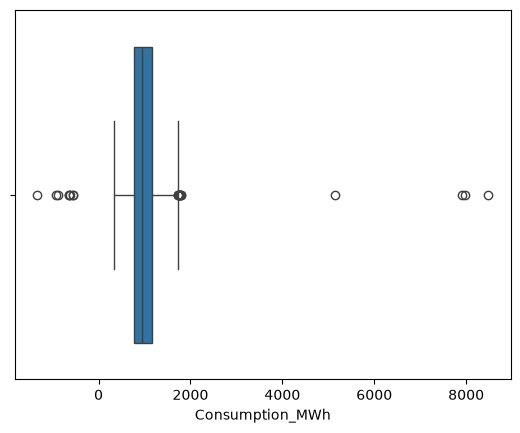

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_clean["Consumption_MWh"])
plt.show()

In [50]:
df_clean[df_clean["Consumption_MWh"] < 0]

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
698,101433,2024-02-29 16:00:00,New York,Commercial,-928.66,1088.40,930.04,76.41,44.19,47.59,No
1155,104442,2024-07-04 01:00:00,California,Residential,-633.06,714.17,717.19,53.08,28.04,70.39,No
1707,104374,2024-07-01 05:00:00,New York,Commercial,-556.45,594.11,631.36,46.47,NaN,40.99,No
2990,104554,2024-07-08 17:00:00,California,Industrial,-1330.55,1457.04,1512.08,63.29,39.05,42.62,Yes
3539,104754,2024-07-17 01:00:00,Florida,Residential,-648.04,625.75,NaN,50.01,34.89,30.52,No
3624,102738,2024-04-24 01:00:00,Florida,Residential,-545.80,535.08,606.99,46.85,29.19,54.76,No
4108,103702,2024-06-03 05:00:00,Texas,Commercial,-892.61,951.96,961.70,56.35,38.72,26.04,No
5024,101083,2024-02-15 02:00:00,New York,Commercial,-627.28,737.11,654.06,62.34,31.91,26.39,No


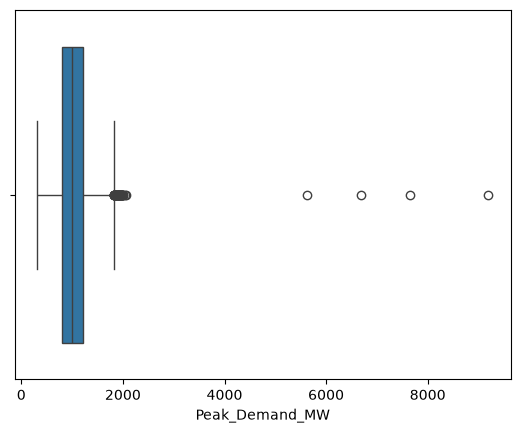

In [51]:
sns.boxplot(x=df_clean["Peak_Demand_MW"])
plt.show()

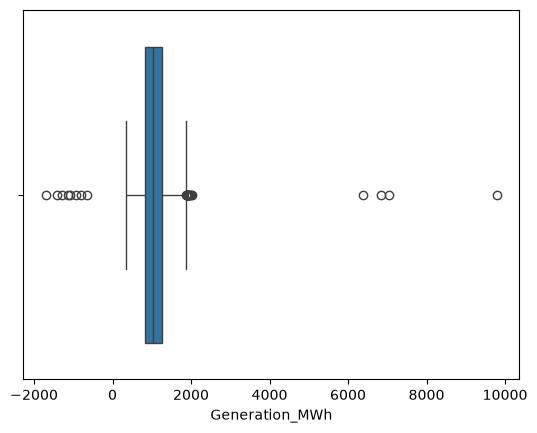

In [52]:
sns.boxplot(x=df_clean["Generation_MWh"])
plt.show()

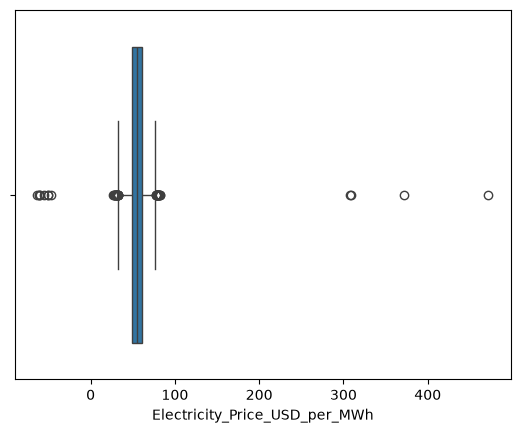

In [53]:
sns.boxplot(x=df_clean["Electricity_Price_USD_per_MWh"])
plt.show()

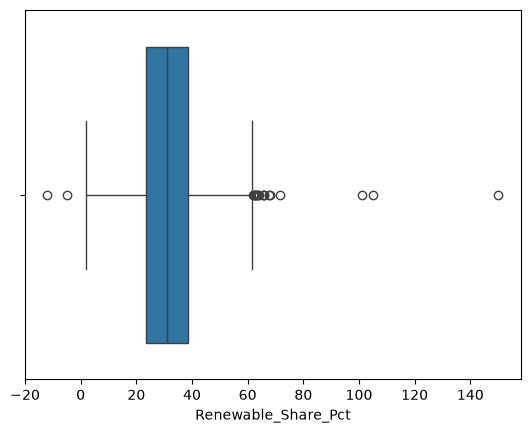

In [54]:
sns.boxplot(x=df_clean["Renewable_Share_Pct"])
plt.show()

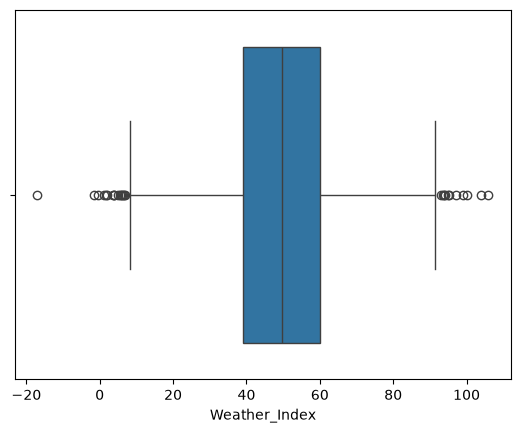

In [55]:
sns.boxplot(x=df_clean["Weather_Index"])
plt.show()

In [56]:
Q1 = df_clean["Consumption_MWh"].quantile(0.25)
Q3 = df_clean["Consumption_MWh"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_clean[
    (df_clean["Consumption_MWh"] < Q1 - 1.5 * IQR) |
    (df_clean["Consumption_MWh"] > Q3 + 1.5 * IQR)
]

len(outliers)

21

In [57]:
outliers[["Record_ID", "Date_Time", "State", "Sector", "Consumption_MWh"]]

,Record_ID,Date_Time,State,Sector,Consumption_MWh
80,101935,2024-03-21 14:00:00,Texas,Industrial,1765.760000
338,103468,2024-05-24 11:00:00,Texas,Industrial,1736.700000
376,100423,2024-01-18 14:00:00,Texas,Industrial,1742.500000
698,101433,2024-02-29 16:00:00,New York,Commercial,-928.660000
1155,104442,2024-07-04 01:00:00,California,Residential,-633.060000
1234,102221,2024-04-02 12:00:00,Texas,Industrial,1787.710000
1539,103283,2024-05-16 18:00:00,California,Commercial,7916.366386
1707,104374,2024-07-01 05:00:00,New York,Commercial,-556.450000
2148,104090,2024-06-19 09:00:00,Texas,Industrial,1736.300000
2279,100529,2024-01-23 00:00:00,Texas,Commercial,5147.613509


In [58]:
(df_clean["Consumption_MWh"] < 0).sum()


np.int64(8)

In [59]:
Q1 = df_clean["Peak_Demand_MW"].quantile(0.25)
Q3 = df_clean["Peak_Demand_MW"].quantile(0.75)
IQR = Q3 - Q1

outliers_peak = df_clean[
    (df_clean["Peak_Demand_MW"] < Q1 - 1.5 * IQR) |
    (df_clean["Peak_Demand_MW"] > Q3 + 1.5 * IQR)
]

len(outliers_peak)

47

In [60]:

outliers_peak[["Record_ID", "Date_Time", "State", "Sector", "Peak_Demand_MW"]]

,Record_ID,Date_Time,State,Sector,Peak_Demand_MW
20,101048,2024-02-13 15:00:00,Texas,Industrial,1894.960000
95,100882,2024-02-06 17:00:00,Texas,Industrial,1974.530000
376,100423,2024-01-18 14:00:00,Texas,Industrial,1852.990000
395,101434,2024-02-29 17:00:00,Texas,Industrial,1957.720000
435,101074,2024-02-14 17:00:00,Texas,Industrial,1872.650000
583,104066,2024-06-18 09:00:00,Texas,Industrial,1850.580000
620,104763,2024-07-17 10:00:00,Texas,Industrial,1825.650000
632,104408,2024-07-02 15:00:00,Texas,Industrial,1994.070000
744,104797,2024-07-18 20:00:00,Texas,Industrial,1845.100000
797,100860,2024-02-05 19:00:00,Texas,Industrial,1932.390000


In [61]:
Q1 = df_clean["Generation_MWh"].quantile(0.25)
Q3 = df_clean["Generation_MWh"].quantile(0.75)
IQR = Q3 - Q1

outliers_generation = df_clean[
    (df_clean["Generation_MWh"] < Q1 - 1.5 * IQR) |
    (df_clean["Generation_MWh"] > Q3 + 1.5 * IQR)
]

len(outliers_generation)

34

In [62]:
outliers_generation[["Record_ID", "Date_Time", "State", "Sector", "Generation_MWh"]]

,Record_ID,Date_Time,State,Sector,Generation_MWh
5,100180,2024-01-08 11:00:00,Texas,Industrial,1921.720000
376,100423,2024-01-18 14:00:00,Texas,Industrial,1917.410000
395,101434,2024-02-29 17:00:00,Texas,Industrial,1884.720000
405,102296,2024-04-05 15:00:00,Texas,Industrial,1904.100000
703,103830,2024-06-08 13:00:00,California,Commercial,6378.977833
750,100512,2024-01-22 07:00:00,New York,Industrial,-1289.570000
854,103621,2024-05-30 20:00:00,Texas,Industrial,1928.050000
898,101002,2024-02-11 17:00:00,Florida,Residential,-919.250000
1052,104726,2024-07-15 21:00:00,Texas,Industrial,1890.060000
1092,100032,2024-01-02 07:00:00,Texas,Industrial,1898.200000


In [63]:
Q1 = df_clean["Electricity_Price_USD_per_MWh"].quantile(0.25)
Q3 = df_clean["Electricity_Price_USD_per_MWh"].quantile(0.75)
IQR = Q3 - Q1

outliers_price = df_clean[
    (df_clean["Electricity_Price_USD_per_MWh"] < Q1 - 1.5 * IQR) |
    (df_clean["Electricity_Price_USD_per_MWh"] > Q3 + 1.5 * IQR)
]

len(outliers_price)

51

In [64]:
outliers_price[["Record_ID", "Date_Time", "State", "Sector", "Electricity_Price_USD_per_MWh"]]

,Record_ID,Date_Time,State,Sector,Electricity_Price_USD_per_MWh
423,100027,2024-01-02 02:00:00,California,Commercial,30.940000
435,101074,2024-02-14 17:00:00,Texas,Industrial,77.930000
436,100587,2024-01-25 10:00:00,Texas,Commercial,78.250000
529,100638,2024-01-27 13:00:00,California,Commercial,31.640000
970,103394,2024-05-21 09:00:00,California,Residential,82.410000
982,101085,2024-02-15 04:00:00,New York,Commercial,32.160000
1076,101889,2024-03-19 16:00:00,Texas,Residential,32.440000
1100,103173,2024-05-12 04:00:00,Texas,Industrial,-60.410000
1139,100271,2024-01-12 06:00:00,California,Residential,28.970000
1345,102797,2024-04-26 12:00:00,Texas,Industrial,80.720000


In [65]:
Q1 = df_clean["Renewable_Share_Pct"].quantile(0.25)
Q3 = df_clean["Renewable_Share_Pct"].quantile(0.75)
IQR = Q3 - Q1

outliers_renewable = df_clean[
    (df_clean["Renewable_Share_Pct"] < Q1 - 1.5 * IQR) |
    (df_clean["Renewable_Share_Pct"] > Q3 + 1.5 * IQR)
]

len(outliers_renewable)

19

In [66]:
outliers_renewable

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
221,102081,2024-03-27 16:00:00,Texas,Commercial,1283.52,1224.26,1441.03,58.45,62.93,25.24,No
522,101438,2024-02-29 21:00:00,Texas,Residential,1173.70,1207.06,1268.98,58.49,-12.00,43.25,No
596,104786,2024-07-18 09:00:00,New York,Residential,977.15,1065.79,1001.60,42.76,67.83,51.54,No
749,101703,2024-03-11 22:00:00,California,NaN,735.60,833.16,809.97,37.15,65.46,56.64,No
1158,103753,2024-06-05 08:00:00,California,Commercial,1119.85,1226.05,1171.50,56.53,62.37,66.27,No
1284,104699,2024-07-14 18:00:00,Texas,Industrial,1480.94,1596.75,1692.33,58.48,65.74,69.98,Yes
1346,103483,2024-05-25 02:00:00,California,Industrial,695.06,701.91,790.35,39.65,62.48,44.03,No
1518,100726,2024-01-31 05:00:00,California,Residential,668.09,657.51,695.08,46.39,61.88,32.82,No
1848,101131,2024-02-17 02:00:00,Texas,Commercial,756.90,782.82,865.02,46.94,65.75,61.11,No
1958,102078,2024-03-27 13:00:00,New York,Industrial,1137.44,1069.29,1235.92,51.10,-5.00,46.12,No


In [67]:
Q1 = df_clean["Weather_Index"].quantile(0.25)
Q3 = df_clean["Weather_Index"].quantile(0.75)
IQR = Q3 - Q1

outliers_weather = df_clean[
    (df_clean["Weather_Index"] < Q1 - 1.5 * IQR) |
    (df_clean["Weather_Index"] > Q3 + 1.5 * IQR)
]

len(outliers_weather)

27

In [68]:
df_clean.corr(numeric_only=True)["Peak_Demand_MW"].sort_values(ascending=False)

Peak_Demand_MW                   1.000000
Consumption_MWh                  0.650441
Generation_MWh                   0.644786
Electricity_Price_USD_per_MWh    0.188429
Weather_Index                    0.005092
Record_ID                       -0.005924
Renewable_Share_Pct             -0.011491
Name: Peak_Demand_MW, dtype: float64

In [69]:
df_clean["Peak_Flag"].value_counts()

Peak_Flag
No     4284
Yes     753
Name: count, dtype: int64